In [1]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# Merging Be stars to Clusters

In [3]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord, search_around_sky, Angle
import astropy.units as u

def match_emitters_to_clusters(
    clusters: pd.DataFrame,
    stars: pd.DataFrame,
    *,
    cluster_ra_col: str = "ra",        # RA dos aglomerados (graus)
    cluster_dec_col: str = "dec",      # Dec dos aglomerados (graus)
    cluster_amaj_col: str = "amaj",    # semi-eixo maior (ex.: arcmin) — tratado como raio circular
    stars_ra_col: str = "ra",          # RA das estrelas (graus)
    stars_dec_col: str = "dec",        # Dec das estrelas (graus)
    amaj_unit: str = "arcmin",         # unidade do amaj (ex.: "arcmin", "arcsec", "deg")
    keep_cols_clusters: list | None = None,  # colunas extras do df de aglomerados para levar ao resultado
    keep_cols_stars: list | None = None,     # colunas extras do df de estrelas para levar ao resultado
) -> pd.DataFrame:
    """
    Associa estrelas Hα a aglomerados retornando apenas as que estão dentro do amaj de cada aglomerado.

    Parameters
    ----------
    clusters : pandas.DataFrame
        Tabela de aglomerados com colunas de posição e amaj.
    stars : pandas.DataFrame
        Tabela de estrelas emissoras com colunas de posição.
    cluster_ra_col : str, default "ra"
        Nome da coluna de RA dos aglomerados (em graus).
    cluster_dec_col : str, default "dec"
        Nome da coluna de Dec dos aglomerados (em graus).
    cluster_amaj_col : str, default "amaj"
        Nome da coluna do semi-eixo maior do aglomerado.
        **É interpretado como um raio circular** para a seleção.
    stars_ra_col : str, default "ra"
        Nome da coluna de RA das estrelas (em graus).
    stars_dec_col : str, default "dec"
        Nome da coluna de Dec das estrelas (em graus).
    amaj_unit : str, default "arcmin"
        Unidade de `amaj` (por exemplo: "arcmin", "arcsec" ou "deg").
    keep_cols_clusters : list[str] | None
        Colunas adicionais do DataFrame de aglomerados a incluir no resultado.
    keep_cols_stars : list[str] | None
        Colunas adicionais do DataFrame de estrelas a incluir no resultado.

    Returns
    -------
    pandas.DataFrame
        Uma tabela já mesclada contendo:
        - índices originais (`cluster_index`, `star_index`)
        - separação angular (`sep_arcsec`, `sep_arcmin`)
        - colunas dos aglomerados com prefixo `cluster_`
        - colunas das estrelas com prefixo `star_`

    Notes
    -----
    * `amaj` é tratado como **semi-eixo maior** em unidade dada por `amaj_unit` e
      usado como **raio circular equivalente** para o corte (i.e., sep <= amaj).
    * A rotina usa um raio máximo global (= max(amaj)) em `search_around_sky`
      e depois filtra par-a-par por `amaj` específico de cada aglomerado.
    * Linhas com posições/raios inválidos (NaN, não positivos) são ignoradas.
    """
    # Escolha das colunas para carregar/propagar
    if keep_cols_clusters is None:
        keep_cols_clusters = []
    if keep_cols_stars is None:
        keep_cols_stars = []

    # Filtrar entradas válidas nos aglomerados
    cl_req = [cluster_ra_col, cluster_dec_col, cluster_amaj_col] + keep_cols_clusters
    cl_df = clusters[cl_req].copy()
    cl_df = cl_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[cluster_ra_col, cluster_dec_col, cluster_amaj_col])
    # descarta amaj <= 0
    cl_df = cl_df[cl_df[cluster_amaj_col] > 0].copy()

    # Filtrar entradas válidas nas estrelas
    st_req = [stars_ra_col, stars_dec_col] + keep_cols_stars
    st_df = stars[st_req].copy()
    st_df = st_df.replace([np.inf, -np.inf], np.nan).dropna(subset=[stars_ra_col, stars_dec_col])

    if cl_df.empty or st_df.empty:
        return pd.DataFrame(columns=[
            "cluster_index","star_index","sep_arcsec","sep_arcmin"
        ])

    # Coordenadas
    c_clusters = SkyCoord(ra=cl_df[cluster_ra_col].to_numpy() * u.deg,
                          dec=cl_df[cluster_dec_col].to_numpy() * u.deg)
    c_stars = SkyCoord(ra=st_df[stars_ra_col].to_numpy() * u.deg,
                       dec=st_df[stars_dec_col].to_numpy() * u.deg)

    # Raio máximo global para a busca
    unit = u.Unit(amaj_unit)
    max_amaj = np.nanmax(cl_df[cluster_amaj_col].to_numpy())
    seplimit = Angle(max_amaj, unit)

    # Busca inicial (eficiente)
    idx_cl, idx_st, sep2d, _ = search_around_sky(c_clusters, c_stars, seplimit=seplimit)

    if len(idx_cl) == 0:
        return pd.DataFrame(columns=[
            "cluster_index","star_index","sep_arcsec","sep_arcmin"
        ])

    # Limite específico por aglomerado (par-a-par)
    amaj_per_pair = Angle(cl_df.iloc[idx_cl][cluster_amaj_col].to_numpy(), unit)
    keep = sep2d <= amaj_per_pair

    if not np.any(keep):
        return pd.DataFrame(columns=[
            "cluster_index","star_index","sep_arcsec","sep_arcmin"
        ])

    # Construir resultado
    pairs = pd.DataFrame({
        "cluster_index": cl_df.index.values[idx_cl[keep]],
        "star_index": st_df.index.values[idx_st[keep]],
        "sep_arcsec": sep2d[keep].arcsec,
        "sep_arcmin": sep2d[keep].to(u.arcmin).value,
    })

    # Anexar metadados dos aglomerados e estrelas (com prefixos)
    cl_out = clusters.loc[pairs["cluster_index"]][[cluster_ra_col, cluster_dec_col, cluster_amaj_col] + keep_cols_clusters]
    cl_out = cl_out.add_prefix("cluster_").reset_index(drop=True)

    st_out = stars.loc[pairs["star_index"]][[stars_ra_col, stars_dec_col] + keep_cols_stars]
    st_out = st_out.add_prefix("star_").reset_index(drop=True)

    result = pd.concat([pairs.reset_index(drop=True), cl_out, st_out], axis=1)

    # Ordenar por separação (útil)
    result = result.sort_values("sep_arcmin", ascending=True).reset_index(drop=True)
    return result

In [41]:
bica = pd.read_csv('/home/marina/FullCatalogBica_08_20.csv')

In [13]:
be = pd.read_csv('/home/shared/splus_gaia/notebooks/magellanic_clouds/studying_diff_objs/selecting_stars_below_be.csv')

In [14]:
# clusters_df: colunas ["name","ra","dec","amaj"] (amaj em arcmin, por ex.)
# emitters_df: colunas ["source_id","ra","dec", ...]
out = match_emitters_to_clusters(
    bica,
    be,
    cluster_ra_col="ra_deg",
    cluster_dec_col="dec_deg",
    cluster_amaj_col="amaj",
    stars_ra_col="ra",
    stars_dec_col="dec",
    amaj_unit="arcmin",
    keep_cols_clusters=["Names"],         # traga o nome do aglomerado
    keep_cols_stars=["id","excess", "err_mag_psf_u", "err_mag_psf_j0378", "err_mag_psf_j0395",
       "err_mag_psf_j0410", "err_mag_psf_j0430", "err_mag_psf_g",
       "err_mag_psf_j0515", "err_mag_psf_r", "err_mag_psf_j0660",
       "err_mag_psf_i", "err_mag_psf_j0861", "err_mag_psf_z", "mag_psf_u",
       "mag_psf_j0378", "mag_psf_j0395", "mag_psf_j0410", "mag_psf_j0430",
       "mag_psf_g", "mag_psf_j0515", "mag_psf_r", "mag_psf_j0660", "mag_psf_i",
       "mag_psf_j0861", "mag_psf_z"]  # traga id/atributos da estrela
)

# "out" tem uma linha por estrela-associada, com "cluster_*" e "star_*"

In [15]:
gp1 = out.groupby('cluster_Names').size().reset_index(name='counts').sort_values(by='counts', ascending=False)

In [16]:
gp1

,cluster_Names,counts
1013,DEMS114,547
1018,DEMS124,471
597,"BS I,Bica-Schmitt I",415
1006,DEMS104,322
634,BS153,296
...,...,...
1244,H86-91,1
405,BMS15,1
1246,"H86-98,SOGLE44",1
1247,"H86-99,SOGLE190",1


In [ ]:
# dtypes = {
#     "id": "string",
#     "ra": "float32",
#     "dec": "float32",
#     "gaia_source_id": "string",
#     "parallax": "float32",
#     "gaia_ruwe": "float32",
#     "gaia_parallax_over_error": "float32",
#     "gaia_classprob_dsc_combmod_star": "float32",
#     "gaia_in_qso_candidates": "int8",
#     "gaia_in_galaxy_candidates": "int8",
#     "gaia_phot_bp_rp_excess_factor": "float32",
#     "err_mag_psf_u": "float32",
#     "err_mag_psf_j0378": "float32",
#     "err_mag_psf_j0395": "float32",
#     "err_mag_psf_j0410": "float32",
#     "err_mag_psf_j0430": "float32",
#     "err_mag_psf_g": "float32",
#     "err_mag_psf_j0515": "float32",
#     "err_mag_psf_r": "float32",
#     "err_mag_psf_j0660": "float32",
#     "err_mag_psf_i": "float32",
#     "err_mag_psf_j0861": "float32",
#     "err_mag_psf_z": "float32",
#     # --- magnitudes ---
#     "mag_psf_u": "float32",
#     "mag_psf_j0378": "float32",
#     "mag_psf_j0395": "float32",
#     "mag_psf_j0410": "float32",
#     "mag_psf_j0430": "float32",
#     "mag_psf_g": "float32",
#     "mag_psf_j0515": "float32",
#     "mag_psf_r": "float32",
#     "mag_psf_j0660": "float32",
#     "mag_psf_i": "float32",
#     "mag_psf_j0861": "float32",
#     "mag_psf_z": "float32"
# }


# full = pd.read_csv(
#     "/mnt/hdcasa/splus_gaia/oficial/MC.csv",
#     engine="pyarrow",
#     dtype=dtypes,
#     usecols=list(dtypes.keys())
# )

# full = full[(full['err_mag_psf_j0660'] < 0.2)&
#         (full['err_mag_psf_i'] < 0.2)&
#         (full['err_mag_psf_r'] < 0.2)&
#         (full['mag_psf_j0660']/full['err_mag_psf_j0660'] > 10)&
#         (full['mag_psf_i']/full['err_mag_psf_i'] > 10)&
#         (full['mag_psf_r']/full['err_mag_psf_r'] > 10)&
#         (full['mag_psf_r'].between(13, 19.5))]

# len(full)


# full.to_csv('all_detections_mc.csv', index=False)

In [4]:
full = pd.read_csv('/home/shared/splus_gaia/notebooks/magellanic_clouds/studying_diff_objs/be_stars/all_detections_mc.csv')

In [ ]:
import numpy as np
import pandas as pd

def _radec_to_unitvec(ra_deg, dec_deg):
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    cosd = np.cos(dec)
    x = cosd * np.cos(ra)
    y = cosd * np.sin(ra)
    z = np.sin(dec)
    return np.column_stack([x, y, z]).astype(np.float32)

def _ang_to_chord(theta_rad):
    # chord distance on unit sphere: d = 2 sin(theta/2)
    return 2.0 * np.sin(theta_rad / 2.0)

def match_stars_to_clusters_stream(
    clusters: pd.DataFrame,
    stars: pd.DataFrame,
    *,
    cluster_ra_col="ra",
    cluster_dec_col="dec",
    cluster_amaj_col="amaj",
    stars_ra_col="ra",
    stars_dec_col="dec",
    amaj_unit="arcmin",
    keep_cols_clusters=None,
    keep_cols_stars=None,
    star_chunksize=500_000,
    return_pairs=True,               # if False: only returns aggregated stats per cluster
    out_path=None,                   # if set: appends results to parquet/csv to avoid holding in RAM
):
    """
    Memory-safe spherical crossmatch:
      - builds KDTree on clusters only
      - streams stars in chunks
      - optionally writes output incrementally

    Requires: scipy
    """
    from scipy.spatial import cKDTree

    if keep_cols_clusters is None: keep_cols_clusters = []
    if keep_cols_stars is None: keep_cols_stars = []

    # --- clean clusters ---
    cl_req = [cluster_ra_col, cluster_dec_col, cluster_amaj_col] + keep_cols_clusters
    cl_df = clusters[cl_req].replace([np.inf, -np.inf], np.nan).dropna(
        subset=[cluster_ra_col, cluster_dec_col, cluster_amaj_col]
    )
    cl_df = cl_df[cl_df[cluster_amaj_col] > 0].copy()
    if cl_df.empty:
        return pd.DataFrame()

    # convert cluster radii to radians
    unit_to_deg = {"deg": 1.0, "arcmin": 1/60, "arcsec": 1/3600}
    if amaj_unit not in unit_to_deg:
        raise ValueError(f"amaj_unit must be one of {list(unit_to_deg)}")
    cl_r_deg = cl_df[cluster_amaj_col].to_numpy(dtype=np.float64) * unit_to_deg[amaj_unit]
    cl_r_rad = np.deg2rad(cl_r_deg)

    # build cluster KDTree in 3D
    cl_vec = _radec_to_unitvec(cl_df[cluster_ra_col].to_numpy(), cl_df[cluster_dec_col].to_numpy())
    tree = cKDTree(cl_vec)

    # global search radius (chord distance)
    max_r = float(np.nanmax(cl_r_rad))
    max_chord = _ang_to_chord(max_r)

    # for outputs
    results = []
    # optional aggregation per cluster
    counts = np.zeros(len(cl_df), dtype=np.int64)
    min_sep_arcsec = np.full(len(cl_df), np.inf, dtype=np.float64)

    # stars index array for mapping back to original indices
    st_req = [stars_ra_col, stars_dec_col] + keep_cols_stars
    st_df_all = stars[st_req].replace([np.inf, -np.inf], np.nan).dropna(subset=[stars_ra_col, stars_dec_col])
    if st_df_all.empty:
        return pd.DataFrame()

    st_idx_all = st_df_all.index.to_numpy()

    # stream chunks
    n = len(st_df_all)
    for s0 in range(0, n, star_chunksize):
        s1 = min(n, s0 + star_chunksize)
        chunk = st_df_all.iloc[s0:s1]
        chunk_idx = st_idx_all[s0:s1]

        st_vec = _radec_to_unitvec(chunk[stars_ra_col].to_numpy(), chunk[stars_dec_col].to_numpy())

        # candidate cluster neighbors for each star (indices into cl_df)
        neigh_lists = tree.query_ball_point(st_vec, r=max_chord)

        # flatten (star_i, cl_i) pairs
        if not any(neigh_lists):
            continue

        star_pos = []
        cl_pos = []
        for i, lst in enumerate(neigh_lists):
            if lst:
                star_pos.extend([i] * len(lst))
                cl_pos.extend(lst)

        star_pos = np.asarray(star_pos, dtype=np.int32)
        cl_pos = np.asarray(cl_pos, dtype=np.int32)

        # compute angular separation (exact) via dot product on unit sphere
        dots = np.einsum("ij,ij->i", st_vec[star_pos], cl_vec[cl_pos]).astype(np.float64)
        dots = np.clip(dots, -1.0, 1.0)
        sep_rad = np.arccos(dots)

        # per-cluster radius filter
        keep = sep_rad <= cl_r_rad[cl_pos]
        if not np.any(keep):
            continue

        star_pos = star_pos[keep]
        cl_pos = cl_pos[keep]
        sep_rad = sep_rad[keep]

        # update aggregations
        np.add.at(counts, cl_pos, 1)
        sep_arcsec = np.rad2deg(sep_rad) * 3600.0
        # min sep per cluster
        # (vectorized "min-at" workaround)
        order = np.argsort(cl_pos)
        cl_sorted = cl_pos[order]
        sep_sorted = sep_arcsec[order]
        # scan blocks
        start = 0
        while start < len(cl_sorted):
            cid = cl_sorted[start]
            end = start + 1
            while end < len(cl_sorted) and cl_sorted[end] == cid:
                end += 1
            m = sep_sorted[start:end].min()
            if m < min_sep_arcsec[cid]:
                min_sep_arcsec[cid] = m
            start = end

        if return_pairs:
            out = pd.DataFrame({
                "cluster_index": cl_df.index.to_numpy()[cl_pos],
                "star_index": chunk_idx[star_pos],
                "sep_arcsec": sep_arcsec,
                "sep_arcmin": sep_arcsec / 60.0,
            })

            # attach metadata lazily (only for matched rows)
            cl_out = clusters.loc[out["cluster_index"], [cluster_ra_col, cluster_dec_col, cluster_amaj_col] + keep_cols_clusters]
            cl_out = cl_out.add_prefix("cluster_").reset_index(drop=True)

            st_out = stars.loc[out["star_index"], [stars_ra_col, stars_dec_col] + keep_cols_stars]
            st_out = st_out.add_prefix("star_").reset_index(drop=True)

            out = pd.concat([out.reset_index(drop=True), cl_out, st_out], axis=1)

            if out_path:
                # safest for huge outputs: write per chunk
                if out_path.endswith(".parquet"):
                    out.to_parquet(out_path, index=False, engine="pyarrow", compression="zstd", append=True)
                else:
                    out.to_csv(out_path, index=False, mode="a", header=not np.exists(out_path))
            else:
                results.append(out)

    if return_pairs and not out_path:
        if results:
            return pd.concat(results, ignore_index=True).sort_values("sep_arcmin").reset_index(drop=True)
        return pd.DataFrame()

    # return aggregation per cluster (super small output)
    agg = cl_df[[cluster_ra_col, cluster_dec_col, cluster_amaj_col] + keep_cols_clusters].copy()
    agg["n_stars_matched"] = counts
    agg["min_sep_arcsec"] = np.where(np.isfinite(min_sep_arcsec), min_sep_arcsec, np.nan)
    return agg

In [6]:
# clusters_df: colunas ["name","ra","dec","amaj"] (amaj em arcmin, por ex.)
# emitters_df: colunas ["source_id","ra","dec", ...]
out2 = match_stars_to_clusters_stream(
    bica,
    full,
    cluster_ra_col="ra_deg",
    cluster_dec_col="dec_deg",
    cluster_amaj_col="amaj",
    stars_ra_col="ra",
    stars_dec_col="dec",
    amaj_unit="arcmin",
    keep_cols_clusters=["Names"],         # traga o nome do aglomerado
    keep_cols_stars=["id", "gaia_source_id",  "err_mag_psf_u", "err_mag_psf_j0378", "err_mag_psf_j0395",
       "err_mag_psf_j0410", "err_mag_psf_j0430", "err_mag_psf_g",
       "err_mag_psf_j0515", "err_mag_psf_r", "err_mag_psf_j0660",
       "err_mag_psf_i", "err_mag_psf_j0861", "err_mag_psf_z", "mag_psf_u",
       "mag_psf_j0378", "mag_psf_j0395", "mag_psf_j0410", "mag_psf_j0430",
       "mag_psf_g", "mag_psf_j0515", "mag_psf_r", "mag_psf_j0660", "mag_psf_i",
       "mag_psf_j0861", "mag_psf_z"]  # traga id/atributos da estrela
)

# "out" tem uma linha por estrela-associada, com "cluster_*" e "star_*"

In [7]:
out2

,cluster_index,star_index,sep_arcsec,sep_arcmin,cluster_ra_deg,cluster_dec_deg,cluster_amaj,cluster_Names,star_ra,star_dec,...,star_mag_psf_j0395,star_mag_psf_j0410,star_mag_psf_j0430,star_mag_psf_g,star_mag_psf_j0515,star_mag_psf_r,star_mag_psf_j0660,star_mag_psf_i,star_mag_psf_j0861,star_mag_psf_z
0,1537,9024072,0.000000,0.000000,80.820830,-70.236110,1.0,HS265,80.844990,-70.237880,...,NaN,20.346657,20.113280,19.821210,19.558699,19.120707,18.835772,18.868717,18.609340,18.546880
1,5503,3199723,0.000000,0.000000,20.216667,-72.532778,2.3,B159,20.232445,-72.543860,...,17.553400,17.547718,17.611395,17.765530,17.780540,18.041523,18.180054,18.310547,18.515112,18.548170
2,5503,3199735,0.000000,0.000000,20.216667,-72.532778,2.3,B159,20.198063,-72.540276,...,19.888874,19.545140,19.436460,19.098330,18.894615,18.619143,18.551958,18.428390,18.380102,18.342700
3,5503,3199737,0.000000,0.000000,20.216667,-72.532778,2.3,B159,20.246944,-72.539444,...,19.133230,19.097187,19.151480,19.288197,19.178060,19.423344,19.563780,19.647856,20.026052,19.723524
4,5503,3199750,0.000000,0.000000,20.216667,-72.532778,2.3,B159,20.240545,-72.539055,...,20.762547,20.484926,20.341381,19.798716,19.652264,19.211246,19.153303,18.973180,18.822931,18.822912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1946550,5736,3187722,7199.567853,119.992798,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",25.834045,-73.421480,...,20.740316,20.333145,19.954956,19.440840,19.200788,18.879017,18.817780,18.672285,18.555313,18.492603
1946551,5736,4732032,7199.567853,119.992798,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",25.834480,-73.421390,...,20.358576,19.825651,19.734732,19.317090,19.168585,18.685099,18.613907,18.395334,18.288310,18.226505
1946552,5736,4723106,7199.920144,119.998669,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",25.040113,-73.858470,...,19.687912,19.465380,19.439308,19.209452,19.067453,18.859980,18.852978,18.795944,18.815159,18.771027
1946553,5736,3188064,7199.920144,119.998669,32.045833,-74.446111,120.0,"BS I,Bica-Schmitt I",26.353388,-73.224110,...,20.895376,21.333120,21.069246,20.236404,19.711428,19.280987,19.096510,18.913187,18.633595,18.626700


In [9]:
gp2 = out2.groupby('cluster_Names').size().reset_index(name='counts').sort_values(by='counts', ascending=False)

In [17]:
gp3 = gp1.merge(gp2, on='cluster_Names', how='outer', suffixes=('_be_stars', '_all_stars')).fillna(0)

In [27]:
gp3['fraction_be_stars'] = gp3['counts_be_stars'] / gp3['counts_all_stars']

In [28]:
bica

,Names,amaj,bmin,l_logAge,logAge,r_logAge,[M/H],r_[M/H],SimbadName,ra_deg,dec_deg,host,region,a_host_deg,phi_host_deg,sep_host_deg
0,L2,1.20,1.20,NaN,NaN,NaN,NaN,NaN,ClLindsay2,3.229170,-73.487500,SMC,SMC: Counter-Bridge,3.782166,152.563464,2.956048
1,"L3,ESO28SC13",1.00,1.00,NaN,NaN,NaN,NaN,NaN,ClLindsay3,4.604170,-74.318610,SMC,SMC: Counter-Bridge,2.956597,170.569541,2.844014
2,BS1,0.90,0.90,NaN,NaN,NaN,NaN,NaN,[BS95]1,4.737500,-73.414440,SMC,SMC: Counter-Bridge,3.231062,152.411427,2.520328
3,BS127,1.00,1.00,NaN,NaN,NaN,NaN,NaN,[BS95]127,16.250000,-71.142780,SMC,SMC: Wing/Bridge,2.102299,14.243756,1.933926
4,BS198,1.00,0.75,NaN,NaN,NaN,NaN,NaN,[BS95]198,27.000000,-73.132780,SMC,SMC: Wing/Bridge,7.068967,-55.859573,4.044193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5842,BBica 19,0.75,0.75,,,,,,NaN,58.424167,-73.934167,LMC,LMC: Northern Arm,11.327972,106.091779,8.083041
5843,ICA74,4.20,2.10,,,,,,ICA74,58.458333,-73.921667,LMC,LMC: Northern Arm,11.311204,106.031494,8.069903
5844,ICA75,2.00,1.40,,,,,,ICA75,60.512500,-74.069444,LMC,LMC: Northern Arm,10.579923,108.607557,7.600472
5845,"IDK6,ICA76",7.00,6.00,<,7.00,"DGI+91,GDK92",,,IDK6,64.870833,-73.896944,LMC,LMC: Northern Arm,8.893757,112.024473,6.458244


In [34]:
frac = gp3.merge(bica[['Names','logAge','[M/H]', 'amaj']], left_on='cluster_Names', right_on='Names', how='left')

In [35]:
frac.to_csv('be_stars_fraction_per_cluster.csv', index=False)

# Processed table with fraction of Be Stars

In [6]:
frac = pd.read_csv('be_stars_fraction_per_cluster.csv')

In [7]:
frac

,cluster_Names,counts_be_stars,counts_all_stars,fraction_be_stars,Names,logAge,[M/H],amaj
0,B-OB1,3.0,360,0.008333,B-OB1,8.20,,3.70
1,B-OB11,1.0,376,0.002660,B-OB11,,,3.00
2,B-OB12,15.0,3543,0.004234,B-OB12,7.60,,4.50
3,B-OB13,54.0,7138,0.007565,B-OB13,6.80,,9.00
4,B-OB14,33.0,9597,0.003439,B-OB14,6.90,,7.00
...,...,...,...,...,...,...,...,...
5559,"ZHT-SP2,LOGLE37",0.0,114,0.000000,"ZHT-SP2,LOGLE37",NaN,NaN,0.95
5560,ZHT12,0.0,60,0.000000,ZHT12,NaN,NaN,0.65
5561,ZHT2,0.0,112,0.000000,ZHT2,NaN,NaN,0.60
5562,"ZHT3,LOGLE88",0.0,135,0.000000,"ZHT3,LOGLE88",NaN,NaN,1.50


In [8]:
frac["logAge"] = pd.to_numeric(frac["logAge"], errors="coerce")

In [35]:
#give me a list of clusters with logAge null and fraction_be_stars > 0.1
frac[(frac['logAge'].isna()) 
     & (frac['fraction_be_stars'] < 0.2)
     ].cluster_Names.tolist()


['B-OB11                                 ',
 'B-OB16                                 ',
 'B1,OGLS 322                            ',
 'B102                                   ',
 'B104                                   ',
 'B107                                   ',
 'B11                                    ',
 'B112ne                                 ',
 'B112sw                                 ',
 'B116                                   ',
 'B118                                   ',
 'B120                                   ',
 'B123                                   ',
 'B13                                    ',
 'B133                                   ',
 'B140                                   ',
 'B142                                   ',
 'B144,H86-200                           ',
 'B146                                   ',
 'B149                                   ',
 'B15                                    ',
 'B150                                   ',
 'B157                          

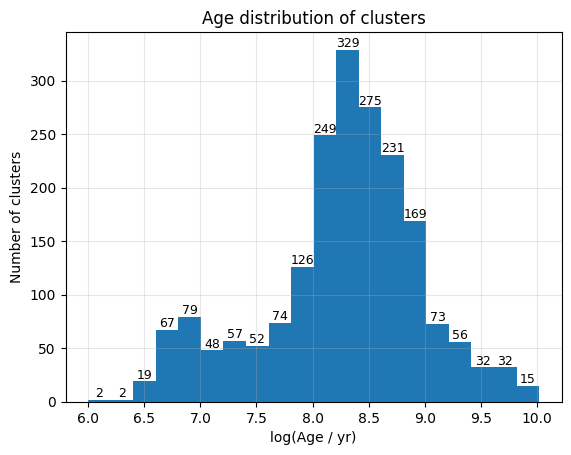

In [9]:
import matplotlib.pyplot as plt
import numpy as np

counts, bin_edges, patches = plt.hist(frac["logAge"], bins=20)

# centro de cada bin
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# adicionar os valores acima das barras
for c, x in zip(counts, bin_centers):
    if c > 0:
        plt.text(x, c, f"{int(c)}", ha="center", va="bottom", fontsize=9)

plt.xlabel("log(Age / yr)")
plt.ylabel("Number of clusters")
plt.title("Age distribution of clusters")
plt.grid(alpha=0.3)

plt.show()

In [10]:
frac['logAge'].describe()

count    1987.000000
mean        8.280720
std         0.691863
min         6.000000
25%         8.000000
50%         8.350000
75%         8.700000
max        10.020000
Name: logAge, dtype: float64

In [11]:
from scipy.stats import beta

alpha = 0.32  # ~68% CI

frac["f_be_low"] = beta.ppf(
    alpha / 2,
    frac["counts_be_stars"] + 1,
    frac["counts_all_stars"] - frac["counts_be_stars"] + 1
)

frac["f_be_high"] = beta.ppf(
    1 - alpha / 2,
    frac["counts_be_stars"] + 1,
    frac["counts_all_stars"] - frac["counts_be_stars"] + 1
)

In [12]:
from scipy.stats import spearmanr

frac2 = frac.dropna(subset=['logAge', 'fraction_be_stars'])

r, p = spearmanr(frac2["logAge"], frac2["fraction_be_stars"])
print(f"Spearman r = {r:.3f}, p = {p:.2e}")

from scipy.stats import kendalltau

tau, p = kendalltau(frac2["logAge"], frac2["fraction_be_stars"])
print(f"Kendall tau = {tau:.3f}, p = {p:.2e}")

Spearman r = -0.255, p = 8.03e-31
Kendall tau = -0.184, p = 5.17e-30


/tmp/ipykernel_3549/4195695508.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = frac.groupby("age_bin")


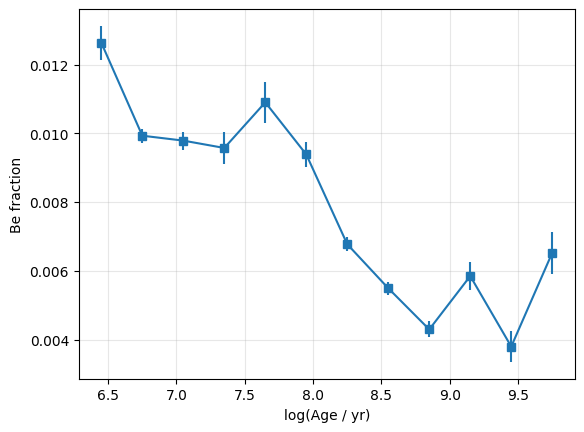

In [13]:
bins = np.arange(6, 10, 0.3)  # ajuste conforme seu range
frac["age_bin"] = pd.cut(frac["logAge"], bins=bins)

grp = frac.groupby("age_bin")

binned = grp.agg(
    n_be=("counts_be_stars", "sum"),
    n_total=("counts_all_stars", "sum")
).reset_index()

binned["fraction_be_stars"] = binned["n_be"] / binned["n_total"]

binned["f_be_err"] = np.sqrt(
    binned["fraction_be_stars"] * (1 - binned["fraction_be_stars"]) / binned["n_total"]
)

bin_centers = bins[:-1] + np.diff(bins)/2

plt.errorbar(
    bin_centers,
    binned["fraction_be_stars"],
    yerr=binned["f_be_err"],
    fmt="s-"
)


plt.xlabel("log(Age / yr)")
plt.ylabel("Be fraction")
plt.grid(alpha=0.3)
plt.show()

In [14]:
from scipy.stats import spearmanr
mask = (
    np.isfinite(bin_centers)
    & np.isfinite(binned["fraction_be_stars"])
    & (binned["n_total"] > 0)
)

x = bin_centers[mask]
y = binned.loc[mask, "fraction_be_stars"]
r_bin, p_bin = spearmanr(
    x,
    y
)

print(r_bin, p_bin)

-0.8671328671328673 0.00025981184986148103


In [15]:
binned[["n_be", "n_total", "fraction_be_stars"]]

,n_be,n_total,fraction_be_stars
0,0.0,0,NaN
1,655.0,51852,0.012632
2,2327.0,234359,0.009929
3,1384.0,141422,0.009786
4,399.0,41682,0.009572
5,331.0,30367,0.010900
6,646.0,68843,0.009384
7,1071.0,158149,0.006772
8,839.0,152759,0.005492
9,334.0,77783,0.004294


In [16]:
frac

,cluster_Names,counts_be_stars,counts_all_stars,fraction_be_stars,Names,logAge,[M/H],amaj,f_be_low,f_be_high,age_bin
0,B-OB1,3.0,360,0.008333,B-OB1,8.2,,3.70,0.005805,0.016288,"(8.1, 8.4]"
1,B-OB11,1.0,376,0.002660,B-OB11,NaN,,3.00,0.001889,0.008696,NaN
2,B-OB12,15.0,3543,0.004234,B-OB12,7.6,,4.50,0.003405,0.005621,"(7.5, 7.8]"
3,B-OB13,54.0,7138,0.007565,B-OB13,6.8,,9.00,0.006677,0.008728,"(6.6, 6.9]"
4,B-OB14,33.0,9597,0.003439,B-OB14,6.9,,7.00,0.002942,0.004142,"(6.9, 7.2]"
...,...,...,...,...,...,...,...,...,...,...,...
5559,"ZHT-SP2,LOGLE37",0.0,114,0.000000,"ZHT-SP2,LOGLE37",NaN,NaN,0.95,0.001515,0.015809,NaN
5560,ZHT12,0.0,60,0.000000,ZHT12,NaN,NaN,0.65,0.002854,0.029596,NaN
5561,ZHT2,0.0,112,0.000000,ZHT2,NaN,NaN,0.60,0.001542,0.016087,NaN
5562,"ZHT3,LOGLE88",0.0,135,0.000000,"ZHT3,LOGLE88",NaN,NaN,1.50,0.001281,0.013384,NaN


In [17]:
frac2

,cluster_Names,counts_be_stars,counts_all_stars,fraction_be_stars,Names,logAge,[M/H],amaj,f_be_low,f_be_high
0,B-OB1,3.0,360,0.008333,B-OB1,8.2,,3.70,0.005805,0.016288
2,B-OB12,15.0,3543,0.004234,B-OB12,7.6,,4.50,0.003405,0.005621
3,B-OB13,54.0,7138,0.007565,B-OB13,6.8,,9.00,0.006677,0.008728
4,B-OB14,33.0,9597,0.003439,B-OB14,6.9,,7.00,0.002942,0.004142
6,B-OB18,54.0,4380,0.012329,B-OB18,6.8,,5.00,0.010883,0.014218
...,...,...,...,...,...,...,...,...,...,...
5536,VMC9,0.0,152,0.000000,VMC9,9.0,,0.60,0.001139,0.011906
5542,"WG13,OGLB 78",0.0,17,0.000000,"WG13,OGLB 78",8.1,-0.30,1.10,0.009640,0.096799
5547,WG17,0.0,19,0.000000,WG17,7.3,,1.20,0.008680,0.087556
5548,"WG17,BS229,OGLB 63",0.0,6,0.000000,"WG17,BS229,OGLB 63",7.3,,0.45,0.024600,0.230333


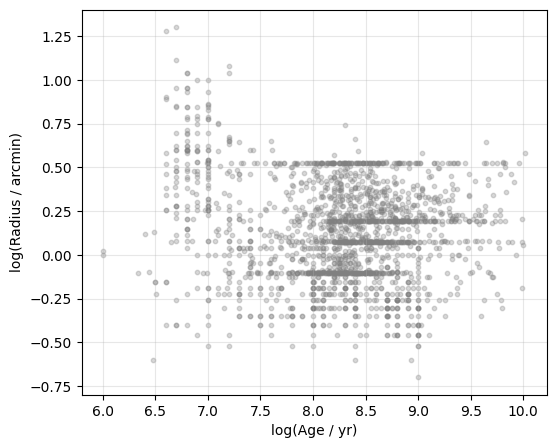

In [18]:
plt.figure(figsize=(6,5))

plt.scatter(
    frac["logAge"],
    np.log10(frac["amaj"]),
    s=10,
    alpha=0.3,
    color="gray"
)

plt.xlabel("log(Age / yr)")
plt.ylabel("log(Radius / arcmin)")
plt.grid(alpha=0.3)
plt.show()

/tmp/ipykernel_3549/3025855809.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby("age_bin")


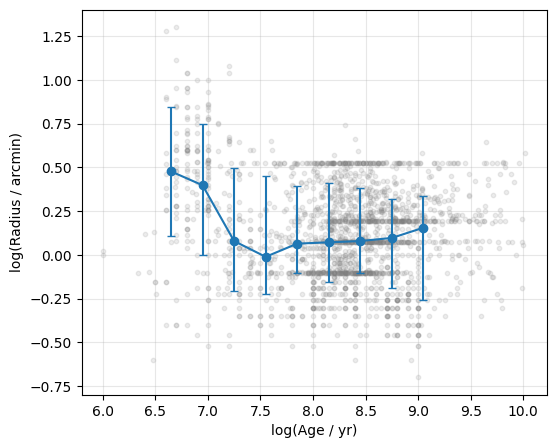

In [19]:
df = frac

bins = np.arange(6.5, 9.5, 0.3)
df["age_bin"] = pd.cut(df["logAge"], bins)

grp = df.groupby("age_bin")

binned = grp["amaj"].agg(
    median="median",
    p16=lambda x: np.percentile(x, 16),
    p84=lambda x: np.percentile(x, 84)
).reset_index()

bin_centers = bins[:-1] + np.diff(bins)/2

plt.figure(figsize=(6,5))

plt.scatter(
    df["logAge"],
    np.log10(df["amaj"]),
    s=10,
    alpha=0.15,
    color="gray"
)

plt.errorbar(
    bin_centers,
    np.log10(binned["median"]),
    yerr=[
        np.log10(binned["median"]) - np.log10(binned["p16"]),
        np.log10(binned["p84"]) - np.log10(binned["median"])
    ],
    fmt="o-",
    color="tab:blue",
    capsize=3
)

plt.xlabel("log(Age / yr)")
plt.ylabel("log(Radius / arcmin)")
plt.grid(alpha=0.3)
plt.show()

<Figure size 1500x1000 with 0 Axes>

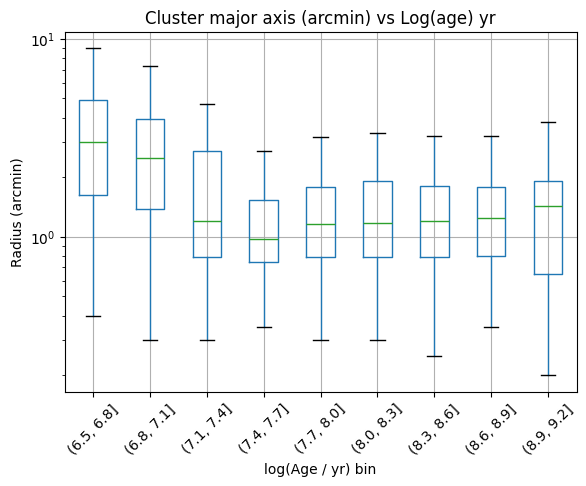

In [20]:
plt.figure(figsize=(15,10))

df.boxplot(
    column="amaj",
    by="age_bin",
    showfliers=False
)

plt.yscale("log")
plt.xlabel("log(Age / yr) bin")
plt.ylabel("Radius (arcmin)")
plt.suptitle("")
plt.title("Cluster major axis (arcmin) vs Log(age) yr")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_3549/4041989134.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby("age_bin")


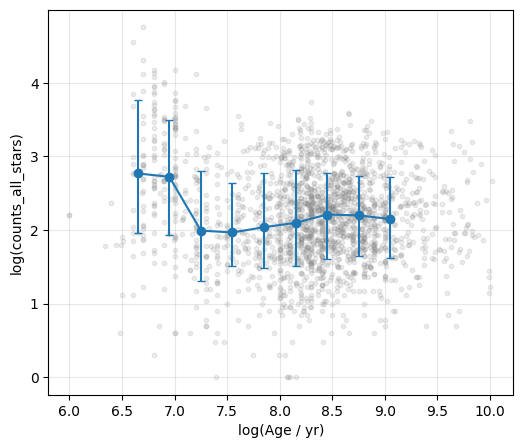

In [21]:
df = frac

bins = np.arange(6.5, 9.5, 0.3)
df["age_bin"] = pd.cut(df["logAge"], bins)

grp = df.groupby("age_bin")

binned = grp["counts_all_stars"].agg(
    median="median",
    p16=lambda x: np.percentile(x, 16),
    p84=lambda x: np.percentile(x, 84)
).reset_index()

bin_centers = bins[:-1] + np.diff(bins)/2

plt.figure(figsize=(6,5))

plt.scatter(
    df["logAge"],
    np.log10(df["counts_all_stars"]),
    s=10,
    alpha=0.15,
    color="gray"
)

plt.errorbar(
    bin_centers,
    np.log10(binned["median"]),
    yerr=[
        np.log10(binned["median"]) - np.log10(binned["p16"]),
        np.log10(binned["p84"]) - np.log10(binned["median"])
    ],
    fmt="o-",
    color="tab:blue",
    capsize=3
)

plt.xlabel("log(Age / yr)")
plt.ylabel("log(counts_all_stars)")
plt.grid(alpha=0.3)
plt.show()

/tmp/ipykernel_3549/1646008776.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frac3["age_bin"] = pd.cut(frac3["logAge"], bins=bins)
/tmp/ipykernel_3549/1646008776.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = frac3.groupby("age_bin")


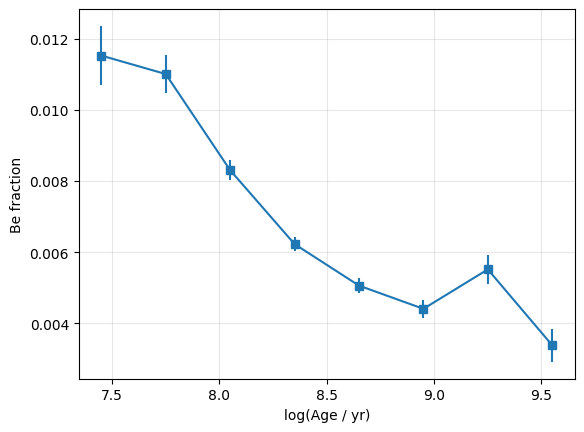

-0.9285714285714287 0.0008629681828999769


In [25]:
frac3 = frac[frac['logAge'].between(7.4, 10.0)]

bins = np.arange(7, 10, 0.3)  # ajuste conforme seu range
frac3["age_bin"] = pd.cut(frac3["logAge"], bins=bins)

grp = frac3.groupby("age_bin")

binned = grp.agg(
    n_be=("counts_be_stars", "sum"),
    n_total=("counts_all_stars", "sum")
).reset_index()

binned["fraction_be_stars"] = binned["n_be"] / binned["n_total"]

binned["f_be_err"] = np.sqrt(
    binned["fraction_be_stars"] * (1 - binned["fraction_be_stars"]) / binned["n_total"]
)

bin_centers = bins[:-1] + np.diff(bins)/2

plt.errorbar(
    bin_centers,
    binned["fraction_be_stars"],
    yerr=binned["f_be_err"],
    fmt="s-"
)


plt.xlabel("log(Age / yr)")
plt.ylabel("Be fraction")
plt.grid(alpha=0.3)
plt.show()


from scipy.stats import spearmanr
mask = (
    np.isfinite(bin_centers)
    & np.isfinite(binned["fraction_be_stars"])
    & (binned["n_total"] > 0)
)

x = bin_centers[mask]
y = binned.loc[mask, "fraction_be_stars"]
r_bin, p_bin = spearmanr(
    x,
    y
)

print(r_bin, p_bin)

In [23]:
import pandas as pd
import numpy as np

x = frac["logAge"]

# Ex.: 10 bins = decíis (0–10%, 10–20%, ...)
frac["age_pct_bin"] = pd.qcut(x, q=20, labels=False, duplicates="drop")  # 0..9

In [24]:
import matplotlib.pyplot as plt

plt.hist(x, bins=edges, edgecolor="black", alpha=0.7)
plt.xlabel("log(Age / yr)")
plt.ylabel("Count")
plt.title("Clusters per quantile bin")
plt.grid(axis="y", alpha=0.3)
plt.show()

NameError: name 'edges' is not defined

In [ ]:
binned = (
    frac.groupby("age_pct_bin")
    .agg(
        n_be=("counts_be_stars", "sum"),
        n_total=("counts_all_stars", "sum"),
        median_logAge=("logAge", "median"),
        min_logAge=("logAge", "min"),
        max_logAge=("logAge", "max"),
        num_clusters=("cluster_Names", "nunique"),
    )
    .reset_index()
)

binned["f_be"] = binned["n_be"] / binned["n_total"]
binned["f_be_err"] = np.sqrt(
    binned["f_be"] * (1 - binned["f_be"]) / binned["n_total"]
)

In [ ]:
binned

,age_pct_bin,n_be,n_total,median_logAge,min_logAge,max_logAge,num_clusters,f_be,f_be_err
0,0.0,3473.0,330837,6.800,6.00,6.90,117,0.010498,0.000177
1,1.0,1085.0,118653,7.000,6.95,7.20,99,0.009144,0.000276
2,2.0,253.0,21951,7.400,7.22,7.53,82,0.011526,0.000720
3,3.0,322.0,30488,7.700,7.54,7.80,101,0.010562,0.000585
4,4.0,356.0,37612,7.950,7.81,8.00,126,0.009465,0.000499
5,5.0,263.0,29306,8.050,8.01,8.09,72,0.008974,0.000551
6,6.0,206.0,28109,8.130,8.10,8.17,107,0.007329,0.000509
7,7.0,257.0,36344,8.200,8.18,8.24,94,0.007071,0.000440
8,8.0,392.0,56107,8.280,8.25,8.30,142,0.006987,0.000352
9,9.0,122.0,20924,8.330,8.31,8.35,57,0.005831,0.000526


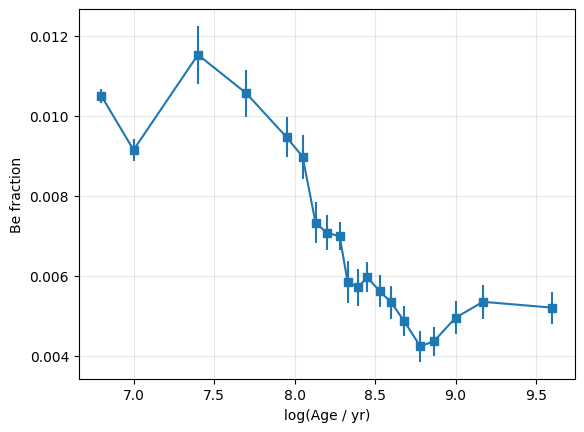

In [ ]:
plt.errorbar(
    binned["median_logAge"],
    binned["f_be"],
    yerr=binned["f_be_err"],
    fmt="s-"
)

plt.xlabel("log(Age / yr)")
plt.ylabel("Be fraction")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from scipy.stats import spearmanr

r, p = spearmanr(
    binned["median_logAge"],
    binned["f_be"]
)

print(r, p)

-0.9248120300751879 5.539165176617526e-09


In [39]:
import re
import pandas as pd
from astroquery.vizier import Vizier

cluster_names = frac[(frac['logAge'].isna()) 
     & (frac['fraction_be_stars'] < 0.2)
     ].cluster_Names.tolist()
# ---- helpers ----
def norm_name(s: str) -> str:
    """Normaliza para bater nomes tipo 'BSDL1018' vs 'BSDL 1018'."""
    s = (s or "").strip()
    s = re.sub(r"\s+", " ", s)
    s = s.upper()
    # remove espaços e pontuação comum para criar chave "agressiva"
    key = re.sub(r"[^A-Z0-9]+", "", s)
    return key

def first_token_before_comma(s: str) -> str:
    s = (s or "").strip()
    return s.split(",", 1)[0].strip()

# ---- 2) baixa o catálogo do VizieR (Glatt+2010) ----
Vizier.ROW_LIMIT = -1
# o catálogo J/A+A/517/A50 tem tabelas; a principal costuma ser "table1" (pode variar)
# A melhor prática é inspecionar as tabelas retornadas.
res = Vizier.get_catalogs("J/A+A/517/A50")

# escolha a "maior" tabela (geralmente a principal com os objetos)
tables = list(res)
tbl = max(tables, key=lambda t: len(t))

df = tbl.to_pandas()

# ---- 3) detecta colunas relevantes ----
# Muitas vezes o id do objeto vem em colunas tipo 'Name'/'Cluster'/'ID' etc.
# Vamos tentar achar automaticamente.
possible_name_cols = [c for c in df.columns if c.lower() in ("name", "id", "cluster", "object")]
if not possible_name_cols:
    # fallback: pega a primeira coluna string-like
    possible_name_cols = [c for c in df.columns if df[c].dtype == object]
name_col = possible_name_cols[0]

# log(age) geralmente vem como 'logAge' ou 'logt' etc.
possible_age_cols = [c for c in df.columns if "log" in c.lower() and ("age" in c.lower() or "t" == c.lower())]
if not possible_age_cols:
    # fallback comum no VizieR
    possible_age_cols = [c for c in df.columns if c.lower() in ("Age")]
age_col = possible_age_cols[0]

# ---- 4) cria índice por nome normalizado ----
df["_name_key"] = df[name_col].astype(str).map(norm_name)
age_map = dict(zip(df["_name_key"], df[age_col]))

# ---- 5) monta a saída (com tentativa por aliases) ----
rows = []
for raw in cluster_names:
    raw = raw.rstrip("\n")
    key_full = norm_name(raw)
    key_first = norm_name(first_token_before_comma(raw))

    log_age = None
    src = "not found (in Glatt+2010 VizieR J/A+A/517/A50)"

    if key_full in age_map and pd.notna(age_map[key_full]):
        log_age = float(age_map[key_full])
        src = "Glatt+2010 (VizieR J/A+A/517/A50)"
    elif key_first in age_map and pd.notna(age_map[key_first]):
        log_age = float(age_map[key_first])
        src = "Glatt+2010 (VizieR J/A+A/517/A50) [matched on first alias]"

    rows.append({"cluster_name": raw.strip(), "log_age": log_age, "source": src})

out = pd.DataFrame(rows)
print(out.head(30))

IndexError: list index out of range

In [38]:
tbl

Name,n_Name,E(B-V),R,l_Age,Age,q_Age,Age2,RAJ2000,DEJ2000,Vmag,e_Vmag,SimbadName,Cross-ID
,,mag,arcmin,,log(yr),,log(yr),,,mag,mag,,
str7,str1,float32,float32,str1,float32,uint8,float32,str8,str9,float32,float32,str17,str46
LMC0020,,0.020,0.750,,8.80,1,--,04 37 51,-69 01 45,13.890,0.14,[SL63] 8,"SL8,LW13,KMHK21"
LMC0021,,0.080,0.290,,8.00,1,--,04 38 07,-68 46 39,14.290,0.14,KMHK22,"NGC1649,ESO55SC31,KMHK22"
LMC0022,,0.080,0.750,,8.50,1,--,04 38 22,-68 40 21,13.110,0.14,NGC1652,"NGC1652,SL10,LW14, ESO55SC32,KMHK23"
LMC0030,,0.020,0.550,,8.30,2,--,04 40 28,-69 38 57,13.730,0.12,[SL63] 14,"SL14,LW21,KMHK28"
LMC0031,,0.020,0.650,,8.70,1,--,04 40 43,-68 21 21,14.210,0.12,[SL63] 15,"SL15,LW23,KMHK29"
LMC0035,,0.030,0.500,,8.90,2,--,04 41 33,-72 23 21,14.850,0.12,LW27,"LW27,KMHK39"
LMC0039,,0.050,0.490,,7.70,1,--,04 42 39,-69 49 12,13.000,0.11,NGC1673,"NGC1673,SL17,LW31, ESO55SC34,KMHK43"
LMC0040,,0.070,0.600,,8.45,1,--,04 42 53,-70 07 28,13.460,0.12,[SL63] 18,"SL18,LW32,HS23,KMHK45"


In [44]:
frac = pd.merge(
    frac,
    bica[['Names','ra_deg','dec_deg']],
    left_on="cluster_Names",
    right_on="Names",
    how="left"
)

In [45]:
frac

,cluster_Names,counts_be_stars,counts_all_stars,fraction_be_stars,Names_x,logAge,[M/H],amaj,f_be_low,f_be_high,age_bin,age_pct_bin,Names_y,ra_deg,dec_deg
0,B-OB1,3.0,360,0.008333,B-OB1,8.2,,3.70,0.005805,0.016288,"(8.0, 8.3]",7.0,B-OB1,11.391667,-73.257222
1,B-OB11,1.0,376,0.002660,B-OB11,NaN,,3.00,0.001889,0.008696,NaN,NaN,B-OB11,13.537500,-72.710833
2,B-OB12,15.0,3543,0.004234,B-OB12,7.6,,4.50,0.003405,0.005621,"(7.4, 7.7]",3.0,B-OB12,13.841667,-72.782500
3,B-OB13,54.0,7138,0.007565,B-OB13,6.8,,9.00,0.006677,0.008728,"(6.5, 6.8]",0.0,B-OB13,14.491667,-72.548333
4,B-OB14,33.0,9597,0.003439,B-OB14,6.9,,7.00,0.002942,0.004142,"(6.8, 7.1]",0.0,B-OB14,14.908333,-72.747222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5563,"ZHT-SP2,LOGLE37",0.0,114,0.000000,"ZHT-SP2,LOGLE37",NaN,NaN,0.95,0.001515,0.015809,NaN,NaN,"ZHT-SP2,LOGLE37",75.833330,-66.981110
5564,ZHT12,0.0,60,0.000000,ZHT12,NaN,NaN,0.65,0.002854,0.029596,NaN,NaN,ZHT12,79.175000,-67.803060
5565,ZHT2,0.0,112,0.000000,ZHT2,NaN,NaN,0.60,0.001542,0.016087,NaN,NaN,ZHT2,75.620830,-66.610830
5566,"ZHT3,LOGLE88",0.0,135,0.000000,"ZHT3,LOGLE88",NaN,NaN,1.50,0.001281,0.013384,NaN,NaN,"ZHT3,LOGLE88",76.475000,-66.733330
